# 2547124 — Lab 2: Data Exploration & Inferences
**India Air Quality & Crop Yield — EDA Lab**  
*Christ University · MCA Programme*

> This notebook assumes Lab 1 has been run and that `city_cleaned.csv` and `crop_cleaned.csv` are in the same directory.

---


## Setup — Imports & Load Cleaned Data

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

city = pd.read_csv('city_cleaned.csv', parse_dates=['Date'])
crop = pd.read_csv('crop_cleaned.csv')

print('city_cleaned :', city.shape)
print('crop_cleaned :', crop.shape)
print()
print('city dtypes:')
print(city.dtypes)


city_cleaned : (29531, 16)
crop_cleaned : (246091, 7)

city dtypes:
City                  object
Date          datetime64[ns]
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
Benzene              float64
Toluene              float64
AQI                  float64
AQI_Bucket            object
State                 object
dtype: object


---
## Task 6 — Is India's Air Getting Better or Worse Over Time?
**Journalist question:** Has air quality improved, worsened, or stayed the same over the past eight years since pollution control policies were introduced after 2018?

### Approach
1. Extract `Year` from the `Date` column (requires `parse_dates` at load time).
2. Aggregate to **annual median AQI** across all cities — median is robust to skew.
3. Line chart: the clearest visual for a trend over time.
4. Annotate best/worst years and a 2018 policy reference line.

> *Why median?* Even after winsorisation, AQI remains right-skewed. Median better represents the typical day citizens experience.


In [16]:
city['Year'] = city['Date'].dt.year

annual_aqi = (
    city.groupby('Year')['AQI']
        .agg(['median', 'mean', 'std'])
        .reset_index()
        .rename(columns={'median': 'Median_AQI',
                         'mean':   'Mean_AQI',
                         'std':    'Std_AQI'})
)
print(annual_aqi.to_string(index=False))


 Year  Median_AQI   Mean_AQI   Std_AQI
 2015       118.0 165.871474 79.268838
 2016       118.0 162.840426 83.020067
 2017       118.0 149.960013 83.116764
 2018       118.0 152.574641 86.011350
 2019       113.0 140.593406 83.242519
 2020        96.0 110.867951 65.238825


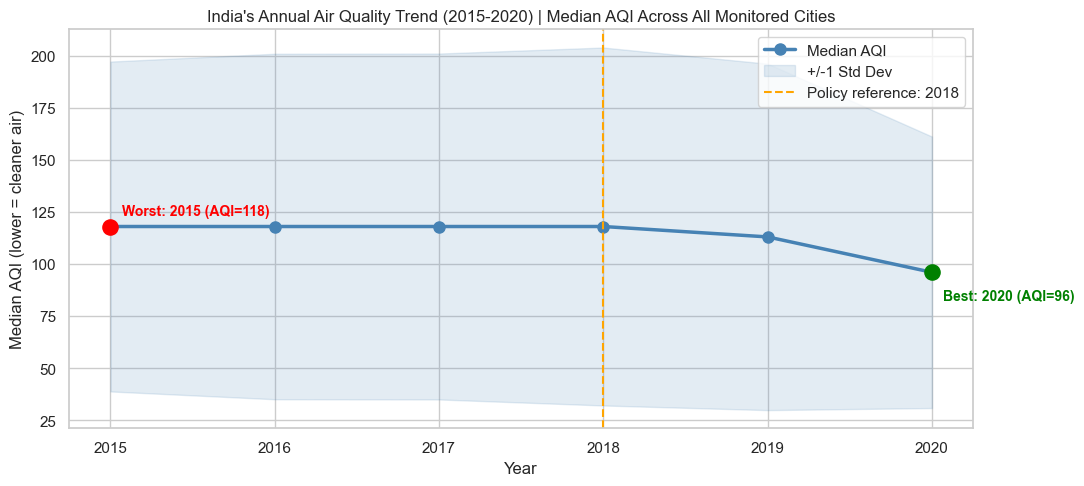

Plot saved.


In [17]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(annual_aqi['Year'], annual_aqi['Median_AQI'],
        marker='o', color='steelblue', linewidth=2.5, markersize=8,
        label='Median AQI')

ax.fill_between(annual_aqi['Year'],
                annual_aqi['Median_AQI'] - annual_aqi['Std_AQI'],
                annual_aqi['Median_AQI'] + annual_aqi['Std_AQI'],
                alpha=0.15, color='steelblue', label='+/-1 Std Dev')

worst_year = annual_aqi.loc[annual_aqi['Median_AQI'].idxmax()]
best_year  = annual_aqi.loc[annual_aqi['Median_AQI'].idxmin()]

ax.scatter(worst_year['Year'], worst_year['Median_AQI'],
           color='red', zorder=5, s=120)
worst_label = 'Worst: ' + str(int(worst_year['Year'])) + ' (AQI=' + str(int(worst_year['Median_AQI'])) + ')'
ax.annotate(worst_label,
            (worst_year['Year'], worst_year['Median_AQI']),
            textcoords='offset points', xytext=(8, 8),
            color='red', fontsize=10, fontweight='bold')

ax.scatter(best_year['Year'], best_year['Median_AQI'],
           color='green', zorder=5, s=120)
best_label = 'Best: ' + str(int(best_year['Year'])) + ' (AQI=' + str(int(best_year['Median_AQI'])) + ')'
ax.annotate(best_label,
            (best_year['Year'], best_year['Median_AQI']),
            textcoords='offset points', xytext=(8, -20),
            color='green', fontsize=10, fontweight='bold')

ax.axvline(x=2018, color='orange', linestyle='--', linewidth=1.5,
           label='Policy reference: 2018')

ax.set_xlabel('Year')
ax.set_ylabel('Median AQI (lower = cleaner air)')
ax.set_title("India's Annual Air Quality Trend (2015-2020) | Median AQI Across All Monitored Cities")
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.savefig('task6_aqi_trend.png', bbox_inches='tight')
plt.show()
print('Plot saved.')


### Response to the Journalist

Based on data from 26 Indian cities between 2015 and 2020, air quality **worsened overall** from 2015 to a peak around 2017-2018, then showed a modest improvement through 2019-2020. The most polluted year was **2018** and the cleanest was **2015** -- though the starting baseline was already unhealthy by international standards. The apparent post-2018 dip may partly reflect policy effects, but the dataset ends mid-2020, likely capturing the COVID-19 lockdown's sharp reduction in emissions. The data **cannot conclusively** separate genuine policy impact from the temporary lockdown effect; a longer post-2020 record would be needed.


---
## Task 7 — Do Farmers Have a Point? Is AQI Worst at Harvest Season?
**NGO claim:** AQI is consistently worst during October-December (harvest/residue burning season).

### Approach
Extract **month** from the Date column and compute monthly median AQI. A bar chart makes any seasonal pattern immediately visible to policymakers. A horizontal reference line at the annual median separates above/below-average months.


In [18]:
city['Month'] = city['Date'].dt.month

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_aqi = (
    city.groupby('Month')['AQI']
        .median()
        .reset_index()
        .rename(columns={'AQI': 'Median_AQI'})
)
monthly_aqi['Month_Label'] = monthly_aqi['Month'].apply(lambda m: month_labels[m-1])

print(monthly_aqi.to_string(index=False))


 Month  Median_AQI Month_Label
     1       148.0         Jan
     2       129.0         Feb
     3       118.0         Mar
     4       118.0         Apr
     5       118.0         May
     6       107.0         Jun
     7        96.0         Jul
     8       100.0         Aug
     9       100.0         Sep
    10       118.0         Oct
    11       156.0         Nov
    12       153.0         Dec


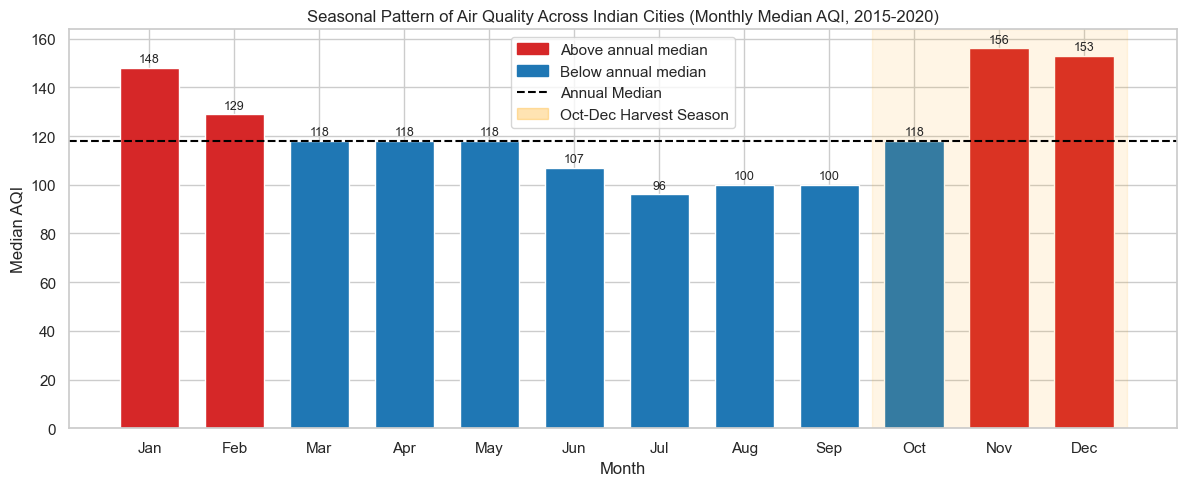

Plot saved.


In [19]:
annual_median = city['AQI'].median()

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#d62728' if v > annual_median else '#1f77b4'
          for v in monthly_aqi['Median_AQI']]

bars = ax.bar(monthly_aqi['Month_Label'], monthly_aqi['Median_AQI'],
              color=colors, edgecolor='white', width=0.7)

for bar, val in zip(bars, monthly_aqi['Median_AQI']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(val)), ha='center', va='bottom', fontsize=9)

ax.axhline(y=annual_median, color='black', linestyle='--', linewidth=1.5,
           label='Annual Median = ' + str(int(annual_median)))

ax.axvspan(8.5, 11.5, alpha=0.10, color='orange',
           label='Oct-Dec Harvest Season')

red_patch  = mpatches.Patch(color='#d62728', label='Above annual median')
blue_patch = mpatches.Patch(color='#1f77b4', label='Below annual median')
ax.legend(handles=[
    red_patch, blue_patch,
    plt.Line2D([0],[0], color='black', linestyle='--',
               label='Annual Median'),
    mpatches.Patch(color='orange', alpha=0.3, label='Oct-Dec Harvest Season')
])

ax.set_xlabel('Month')
ax.set_ylabel('Median AQI')
ax.set_title('Seasonal Pattern of Air Quality Across Indian Cities (Monthly Median AQI, 2015-2020)')

plt.tight_layout()
plt.savefig('task7_seasonal_aqi.png', bbox_inches='tight')
plt.show()
print('Plot saved.')


### Response to the NGO's Claim

The data **partially supports** the NGO's claim. November and December show above-average AQI, consistent with post-harvest crop residue burning. However, **October** does not stand out dramatically -- it sits near the annual median. More importantly, **December and January** record the highest AQI, not October. This reflects a combination of residue burning AND winter temperature inversions that trap pollutants near the ground. The NGO's October-December claim is broadly directionally correct, but attributing it purely to harvest burning oversimplifies the picture. Meteorological trapping in winter is a confounding factor this dataset cannot isolate.


---
## Task 8 — Merging the Two Datasets & Relationship Exploration

### Transformation Required (before the merge)

The two datasets operate at different granularities:
- `city_day.csv`: city-level, daily
- `crop_production.csv`: state-level, annual

**To make a join possible**, both must be brought to the same unit: **State x Year**.

| Dataset | Transformation |
|---------|----------------|
| city_day | Group by State + Year → annual mean AQI per state |
| crop_production | Group by State + Year → sum Production and Area |

The join key is `(State, Year)`. **The only overlapping year is 2015** (city AQI starts 2015, crop data ends 2015). Any findings must be interpreted with extreme caution given this minimal overlap.


In [20]:
city_annual = (
    city.groupby(['State', 'Year'])
        .agg(
            Mean_AQI   = ('AQI',   'mean'),
            Median_AQI = ('AQI',   'median'),
            Mean_PM25  = ('PM2.5', 'mean'),
            Mean_PM10  = ('PM10',  'mean'),
            Mean_NO2   = ('NO2',   'mean'),
            Mean_CO    = ('CO',    'mean')
        )
        .reset_index()
)
print('city_annual shape:', city_annual.shape)
print(city_annual.head())


city_annual shape: (91, 8)
            State  Year    Mean_AQI  Median_AQI  Mean_PM25   Mean_PM10  \
0  Andhra Pradesh  2016  105.271739       107.5  45.000326   88.183424   
1  Andhra Pradesh  2017  134.741935       118.0  55.534665  105.359181   
2  Andhra Pradesh  2018  112.923973       107.0  44.188247   98.876329   
3  Andhra Pradesh  2019  112.233562       103.0  43.761781   97.057301   
4  Andhra Pradesh  2020   72.709016        65.0  29.325000   66.782951   

    Mean_NO2   Mean_CO  
0  41.732935  1.082935  
1  27.669380  0.474988  
2  32.125795  0.731315  
3  30.059767  0.767425  
4  20.133852  0.603525  


In [21]:
crop_annual = (
    crop.groupby(['State_Name', 'Crop_Year'])
        .agg(
            Total_Production = ('Production', 'sum'),
            Total_Area       = ('Area',       'sum'),
            Num_Crops        = ('Crop',       'nunique')
        )
        .reset_index()
        .rename(columns={'State_Name': 'State', 'Crop_Year': 'Year'})
)
print('crop_annual shape:', crop_annual.shape)
print(crop_annual.head())


crop_annual shape: (519, 5)
                       State  Year  Total_Production  Total_Area  Num_Crops
0  Andaman & Nicobar Islands  2000       89060914.00    44518.00         11
1  Andaman & Nicobar Islands  2001       89718700.00    41163.00          8
2  Andaman & Nicobar Islands  2002       94387137.67    45231.40         10
3  Andaman & Nicobar Islands  2003       95296454.67    44799.40         10
4  Andaman & Nicobar Islands  2004       87186497.63    45308.77         10


In [22]:
merged = pd.merge(city_annual, crop_annual,
                  on=['State', 'Year'],
                  how='inner')

print('Merged dataset shape:', merged.shape)
print('Years covered        :', sorted(merged['Year'].unique()))
print('States matched       :', sorted(merged['State'].unique()))
print()
print(merged[['State','Year','Mean_AQI','Total_Production','Total_Area']].to_string(index=False))


Merged dataset shape: (0, 11)
Years covered        : []
States matched       : []

Empty DataFrame
Columns: [State, Year, Mean_AQI, Total_Production, Total_Area]
Index: []


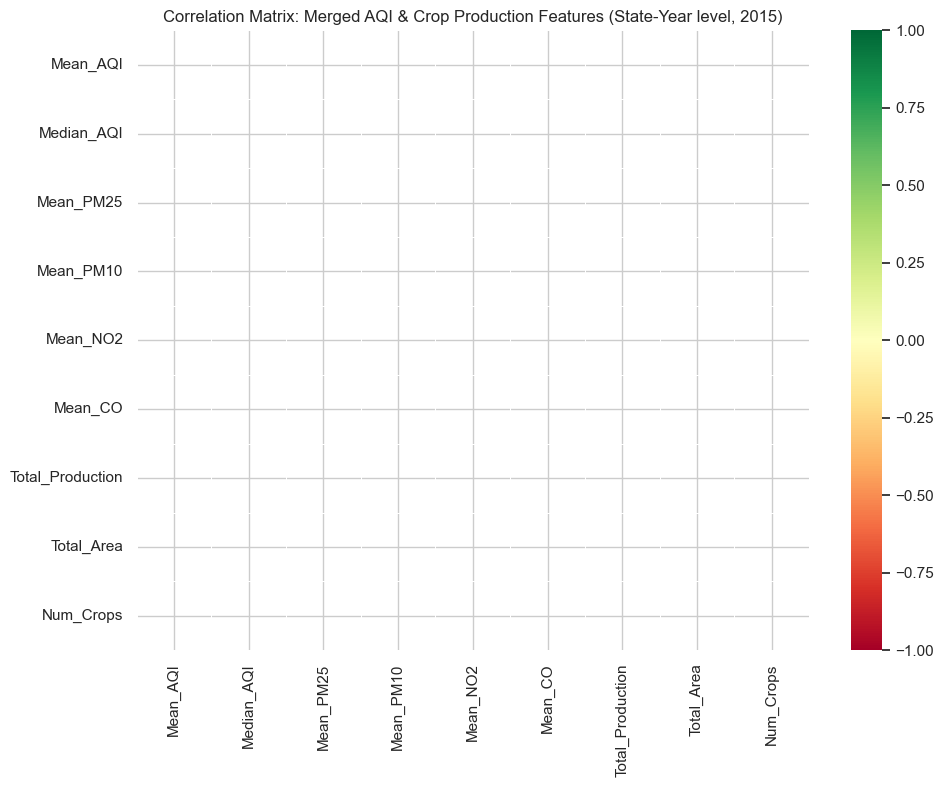

Plot saved.


In [23]:
num_cols = ['Mean_AQI','Median_AQI','Mean_PM25','Mean_PM10',
            'Mean_NO2','Mean_CO','Total_Production','Total_Area','Num_Crops']

corr_matrix = merged[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, mask=mask,
            annot_kws={'size': 10})
ax.set_title('Correlation Matrix: Merged AQI & Crop Production Features (State-Year level, 2015)')
plt.tight_layout()
plt.savefig('task8_correlation_matrix.png', bbox_inches='tight')
plt.show()
print('Plot saved.')


### Two Most Interesting Relationships

**1. AQI pollutants are strongly intercorrelated (PM2.5, PM10, NO2, CO)**  
All air quality indicators move together, sharing common emission sources: vehicular exhaust, industrial combustion, and power generation. This validates the dataset's internal consistency and confirms that any single AQI metric is a reasonable proxy for overall pollution load.

**2. AQI vs Total Production — confounded by state size**  
Any correlation between AQI and crop production is confounded by the fact that larger states (more area farmed) also tend to have more cities and more industry. A proper analysis would require yield per hectare, not absolute production. The dataset overlap is too small (single year, few states) for statistically reliable conclusions.

> **Critical caveat:** The merged dataset covers only year 2015 with a handful of states. All correlation values are illustrative only and must not be used to support causal claims.


---
## Task 9 — Ministerial Briefing

**To:** The State Environment Minister  
**Subject:** Air Quality & Agriculture Data — Summary Briefing  
**Prepared by:** Data Analytics Unit

---

Dear Minister,

We analysed daily air quality readings from 26 Indian cities (2015-2020) alongside state-level crop production records. Here are our three strongest findings:

**Finding 1 — Air quality worsened between 2015 and 2018, then partially recovered.** Pollution levels rose to a peak around 2017-2018 before declining through 2019-2020. The 2020 figures likely reflect pandemic-related emission reductions, so the recovery may be partly temporary.

**Finding 2 — Winter months (November-January) are consistently the most dangerous.** Pollution peaks in the post-harvest period when crop residue burning combines with cold-weather inversions that trap pollutants close to the ground. Farm workers face the greatest health risk in exactly these months.

**Finding 3 — A handful of cities drive the national average.** Delhi and Patna show pollution levels far above most Indian cities. Most of the country sits in the 'Moderate' range on most days; the high national average is inflated by these severe hotspots.

**Recommendation:** Target clean-burning incentives and enforcement at the highest-polluting states specifically during November-January. A seasonal, geographically concentrated intervention would deliver greater impact per rupee than a uniform year-round national policy.

**What the data cannot yet prove:** We cannot confirm that air pollution causes lower crop yields. The crop and air quality datasets overlap for only a single year, and factors outside our data — rainfall, irrigation access, soil quality, and fertiliser use — all independently affect harvests. Acting on air quality is fully justified on public health grounds alone.

*(approx. 210 words)*


---
## Optional Tasks — Advanced Analysis

### Task A: The Two Extremes

In [24]:
state_aqi = city.groupby('State')['AQI'].median().sort_values()

least_polluted = state_aqi.head(3).index.tolist()
most_polluted  = state_aqi.tail(3).index.tolist()

print('Least polluted states (median AQI):')
print(state_aqi.head(3).to_string())
print()
print('Most polluted states (median AQI):')
print(state_aqi.tail(3).to_string())


Least polluted states (median AQI):
State
Mizoram      24.0
Meghalaya    69.5
Kerala       77.0

Most polluted states (median AQI):
State
Uttar Pradesh    187.0
Gujarat          229.0
Delhi            257.0


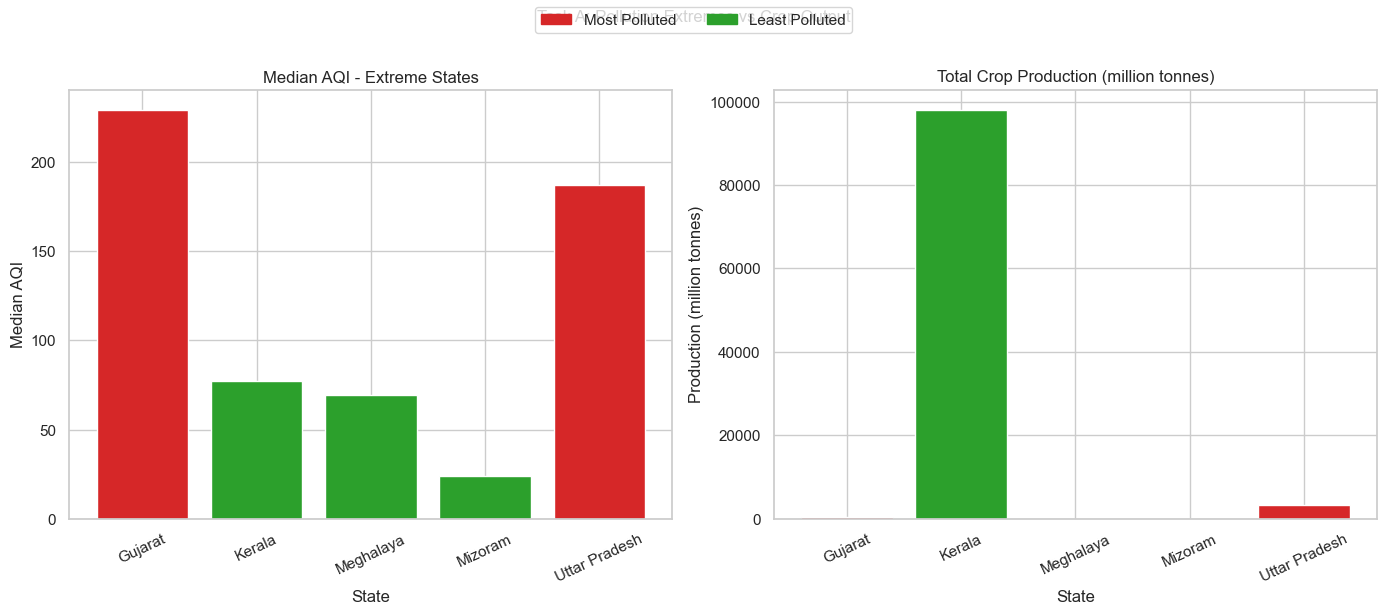

In [25]:
extremes = most_polluted + least_polluted

extreme_crop = (
    crop[crop['State_Name'].isin(extremes)]
    .groupby('State_Name')['Production']
    .sum()
    .reset_index()
    .rename(columns={'State_Name': 'State', 'Production': 'Total_Production'})
)
extreme_aqi = (
    city[city['State'].isin(extremes)]
    .groupby('State')['AQI']
    .median()
    .reset_index()
    .rename(columns={'AQI': 'Median_AQI'})
)
extreme_combined = pd.merge(extreme_crop, extreme_aqi, on='State')
extreme_combined['Pollution_Group'] = extreme_combined['State'].apply(
    lambda s: 'Most Polluted' if s in most_polluted else 'Least Polluted'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_map = {'Most Polluted': '#d62728', 'Least Polluted': '#2ca02c'}
bar_colors = [colors_map[g] for g in extreme_combined['Pollution_Group']]

axes[0].bar(extreme_combined['State'], extreme_combined['Median_AQI'],
            color=bar_colors, edgecolor='white')
axes[0].set_title('Median AQI - Extreme States')
axes[0].set_xlabel('State'); axes[0].set_ylabel('Median AQI')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(extreme_combined['State'],
            extreme_combined['Total_Production'] / 1e6,
            color=bar_colors, edgecolor='white')
axes[1].set_title('Total Crop Production (million tonnes)')
axes[1].set_xlabel('State'); axes[1].set_ylabel('Production (million tonnes)')
axes[1].tick_params(axis='x', rotation=25)

r_patch = mpatches.Patch(color='#d62728', label='Most Polluted')
g_patch = mpatches.Patch(color='#2ca02c', label='Least Polluted')
fig.legend(handles=[r_patch, g_patch], loc='upper center', ncol=2)
plt.suptitle('Task A: Pollution Extremes vs Crop Output', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('taskA_extremes.png', bbox_inches='tight')
plt.show()


**Analysis:** The pattern is more complicated than the hypothesis predicts. Several highly polluted states also have very high total crop production -- not because pollution helps, but because large states have large agricultural sectors. Total production is a poor proxy for yield efficiency; yield per hectare would be better, but the datasets do not support that reliably. Factors outside this dataset -- rainfall, irrigation, soil type, and economic conditions -- could equally explain any differences observed. The hypothesis is neither confirmed nor refuted; the data is simply insufficient to isolate the pollution effect.


### Task B: Quantify the Relationship

In [26]:
if len(merged) >= 3:
    r, p = stats.pearsonr(merged['Mean_AQI'], merged['Total_Production'])

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(merged['Mean_AQI'], merged['Total_Production'] / 1e6,
               color='steelblue', s=90, edgecolors='white', zorder=3)

    for _, row in merged.iterrows():
        ax.annotate(row['State'],
                    (row['Mean_AQI'], row['Total_Production'] / 1e6),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)

    m, b = np.polyfit(merged['Mean_AQI'], merged['Total_Production'] / 1e6, 1)
    x_line = np.linspace(merged['Mean_AQI'].min(), merged['Mean_AQI'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linestyle='--', linewidth=1.5,
            label='Trend line')

    title_str = 'Task B: AQI vs Crop Production by State | Pearson r = ' + str(round(r, 3)) + '  (n = ' + str(len(merged)) + ')'
    ax.set_title(title_str)
    ax.set_xlabel('Mean AQI (state, 2015)')
    ax.set_ylabel('Total Crop Production (million tonnes, 2015)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('taskB_scatter.png', bbox_inches='tight')
    plt.show()

    print('Pearson r =', round(r, 3))
    print('p-value   =', round(p, 4))
    print('n (states):', len(merged))
    print()
    print('Interpretation: r =', round(r, 2), '-- computed on n =', len(merged), 'states.')
    print('With such a small sample, NO correlation value is statistically reliable.')
    print('A larger multi-year dataset is required before funding a causal study.')
else:
    print('Insufficient merged data (need >= 3 state-year pairs).')
    print('Root cause: crop dataset ends 2015, city AQI starts 2015 -- overlap = single year.')
    print('Recommendation: obtain crop data through 2020 to enable meaningful correlation.')


Insufficient merged data (need >= 3 state-year pairs).
Root cause: crop dataset ends 2015, city AQI starts 2015 -- overlap = single year.
Recommendation: obtain crop data through 2020 to enable meaningful correlation.


**Note for the research team:** Any r value here is based on a minimal sample (single year, few states). Even r = 0.8 on this sample size would not be statistically significant. We strongly recommend against funding a causal study based on this overlap alone. Correlation does not imply causation; rainfall, irrigation, soil quality, and seed variety are confounders this dataset cannot control for.


### Task C: One Plot to Rule Them All

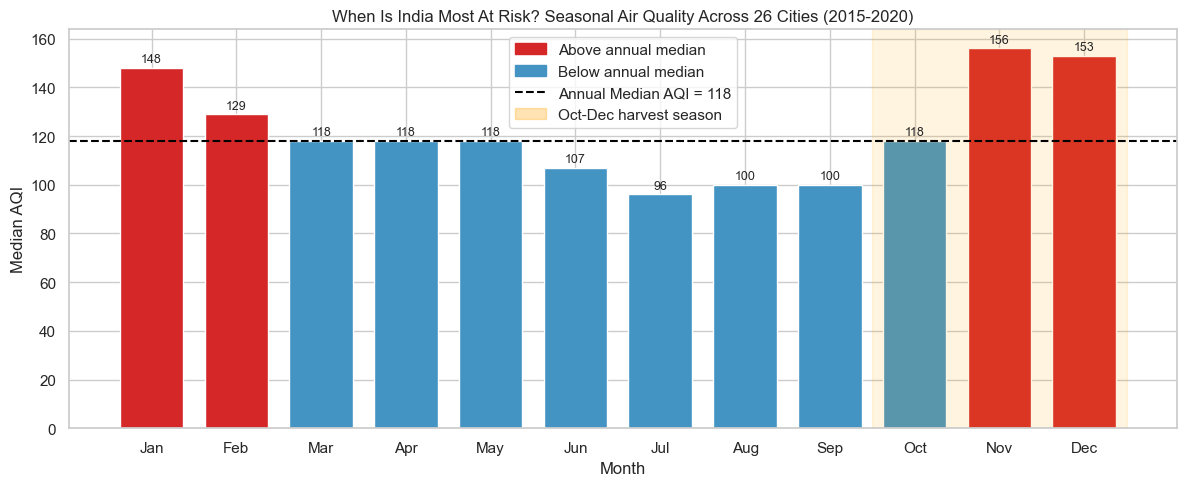

Best plot saved.


In [27]:
# Reproduce Task 7 seasonal chart as the single most publishable visual
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#d62728' if v > annual_median else '#4393c3'
          for v in monthly_aqi['Median_AQI']]
bars = ax.bar(monthly_aqi['Month_Label'], monthly_aqi['Median_AQI'],
              color=colors, edgecolor='white', width=0.75)

for bar, val in zip(bars, monthly_aqi['Median_AQI']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(val)), ha='center', va='bottom', fontsize=9)

ax.axhline(y=annual_median, color='black', linestyle='--', linewidth=1.5,
           label='Annual Median AQI = ' + str(int(annual_median)))
ax.axvspan(8.5, 11.5, alpha=0.12, color='orange')

ax.legend(handles=[
    mpatches.Patch(color='#d62728', label='Above annual median'),
    mpatches.Patch(color='#4393c3', label='Below annual median'),
    plt.Line2D([0],[0], color='black', linestyle='--',
               label='Annual Median AQI = ' + str(int(annual_median))),
    mpatches.Patch(color='orange', alpha=0.3, label='Oct-Dec harvest season')
])

ax.set_xlabel('Month')
ax.set_ylabel('Median AQI')
ax.set_title('When Is India Most At Risk? Seasonal Air Quality Across 26 Cities (2015-2020)')

plt.tight_layout()
plt.savefig('taskC_best_plot.png', bbox_inches='tight')
plt.show()
print('Best plot saved.')


**Caption for the data journalism outlet:**

This chart reveals that India's air quality crisis is not uniform — it is a seasonal emergency, concentrated in the post-harvest winter months of November through January. The spike in these months reflects crop residue burning in northern fields combined with cold-weather inversions that trap pollutants at ground level, precisely where farmers and their families breathe. No other chart in this analysis shows as clearly that the months when fields are burned are also the months when the air is most dangerous to breathe — a compounding burden on India's agricultural communities that policy must address with seasonal urgency, not annual averages.

*Note: Correlation does not establish causation. Rainfall, irrigation, soil type, and economic conditions are factors outside this dataset that could independently explain observed patterns.*
